# Preamble

In [1]:
import warnings
import logging
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
from mlflow.client import MlflowClient
from  sklearn.metrics import mean_absolute_error, mean_squared_error, \
    root_mean_squared_log_error
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse 
import joblib, tempfile

os.environ["MLFLOW_ENABLE_SYSTEM_METRICS_LOGGING"] = "true"

2
logging.getLogger("mlflow").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

# Enable PyTorch Lightning autologging
mlflow.pytorch.autolog(
    log_every_n_epoch=1,
    log_models=True,
    disable=False
)

experiment_name = "store_sales_forecasting"


In [2]:
# Callable function to compute RMSLE using utilsforecast evaluate function
def rmsle(df, models, id_col='unique_id', target_col='y'):
    out = {id_col: [], 'metric': []}
    for uid, g in df.groupby(id_col):
        out[id_col].append(uid)
        out['metric'].append('rmsle')
        for m in models:
            out.setdefault(m, []).append(
                root_mean_squared_log_error(g[target_col], g[m])
            )
    return pd.DataFrame(out)

In [3]:
from pathlib import Path

# Resolve project root dynamically
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

db_path = project_root / "mlflow.db"
artifact_path = project_root / "mlartifacts"

# Set tracking URI to SQLite
mlflow.set_tracking_uri(f"sqlite:///{db_path.as_posix()}")

# Create experiment with explicit artifact destination
client = MlflowClient()

experiment = client.get_experiment_by_name(experiment_name)
if experiment is None:
    client.create_experiment(
        name=experiment_name,
        artifact_location=artifact_path.as_uri()
    )

mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:///home/on1link/Applications/projects/store_sales/store_sales_forecasting/mlartifacts', creation_time=1787761182352, effective_trace_archival_retention=None, experiment_id='6', last_update_time=1787761182352, lifecycle_stage='active', name='store_sales_forecasting', tags={}, trace_location=None, workspace='default'>

In [4]:
kagglehub.login()

In [5]:
competition_name = "store-sales-time-series-forecasting"
path = kagglehub.competition_download(competition_name)

In [6]:
type(path)
print("".join([path, '/train.csv']))

/home/on1link/.cache/kagglehub/competitions/store-sales-time-series-forecasting/train.csv


# Data Ingestion

In [7]:
train_path = "".join([path, '/train.csv'])

In [8]:
train = pd.read_csv("".join([path, '/train.csv']), parse_dates=['date'])
stores = pd.read_csv("".join([path, '/stores.csv']))

# Exploratory Data Analysis

## Dataset Overview

In [9]:
print(train.head(5), "\n", train.tail(5))

   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0 
               id       date  store_nbr                      family     sales  \
3000883  3000883 2017-08-15          9                     POULTRY   438.133   
3000884  3000884 2017-08-15          9              PREPARED FOODS   154.553   
3000885  3000885 2017-08-15          9                     PRODUCE  2419.729   
3000886  3000886 2017-08-15          9  SCHOOL AND OFFICE SUPPLIES   121.000   
3000887  3000887 2017-08-15          9                     SEAFOOD    16.000   

         onpromotion  
3000883            0  
3000884            1  
3000885          148  
3000886            8  
3000887            0  


In [10]:
print(train.columns)

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')


In [11]:
train.describe()

,id,date,store_nbr,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01


In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [13]:
print(f"Number of categories or families and names: {train['family'].nunique()} \n {train['family'].unique()[:]}")


Number of categories or families and names: 33 
 ['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


## Feature Engineering

In [14]:
train['unique_id'] = train['store_nbr'].astype('str') + '_' + train['family']

In [15]:
print(train.columns)
print(stores.columns)

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion',
       'unique_id'],
      dtype='object')
Index(['store_nbr', 'city', 'state', 'type', 'cluster'], dtype='object')


In [16]:
train.drop(columns='unique_id')

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [17]:
print(f"Unique Time Series Count: {train['unique_id'].nunique()}")

Unique Time Series Count: 1782


In [18]:
print(f"Date rage: {train['date'].min()} - {train['date'].max()}")

Date rage: 2013-01-01 00:00:00 - 2017-08-15 00:00:00


## Forecasting DataFrame

In [19]:
df = train[["unique_id", "date", "sales"]].rename(columns={"date": "ds", "sales": "y"})

In [20]:
df

,unique_id,ds,y
0,1_AUTOMOTIVE,2013-01-01,0.000
1,1_BABY CARE,2013-01-01,0.000
2,1_BEAUTY,2013-01-01,0.000
3,1_BEVERAGES,2013-01-01,0.000
4,1_BOOKS,2013-01-01,0.000
...,...,...,...
3000883,9_POULTRY,2017-08-15,438.133
3000884,9_PREPARED FOODS,2017-08-15,154.553
3000885,9_PRODUCE,2017-08-15,2419.729
3000886,9_SCHOOL AND OFFICE SUPPLIES,2017-08-15,121.000


In [21]:
zero_pct = (df['y'] == 0).mean()
print(f"Zero sales percentage: {zero_pct:.1%}")

Zero sales percentage: 31.3%


## Time Series Patterns

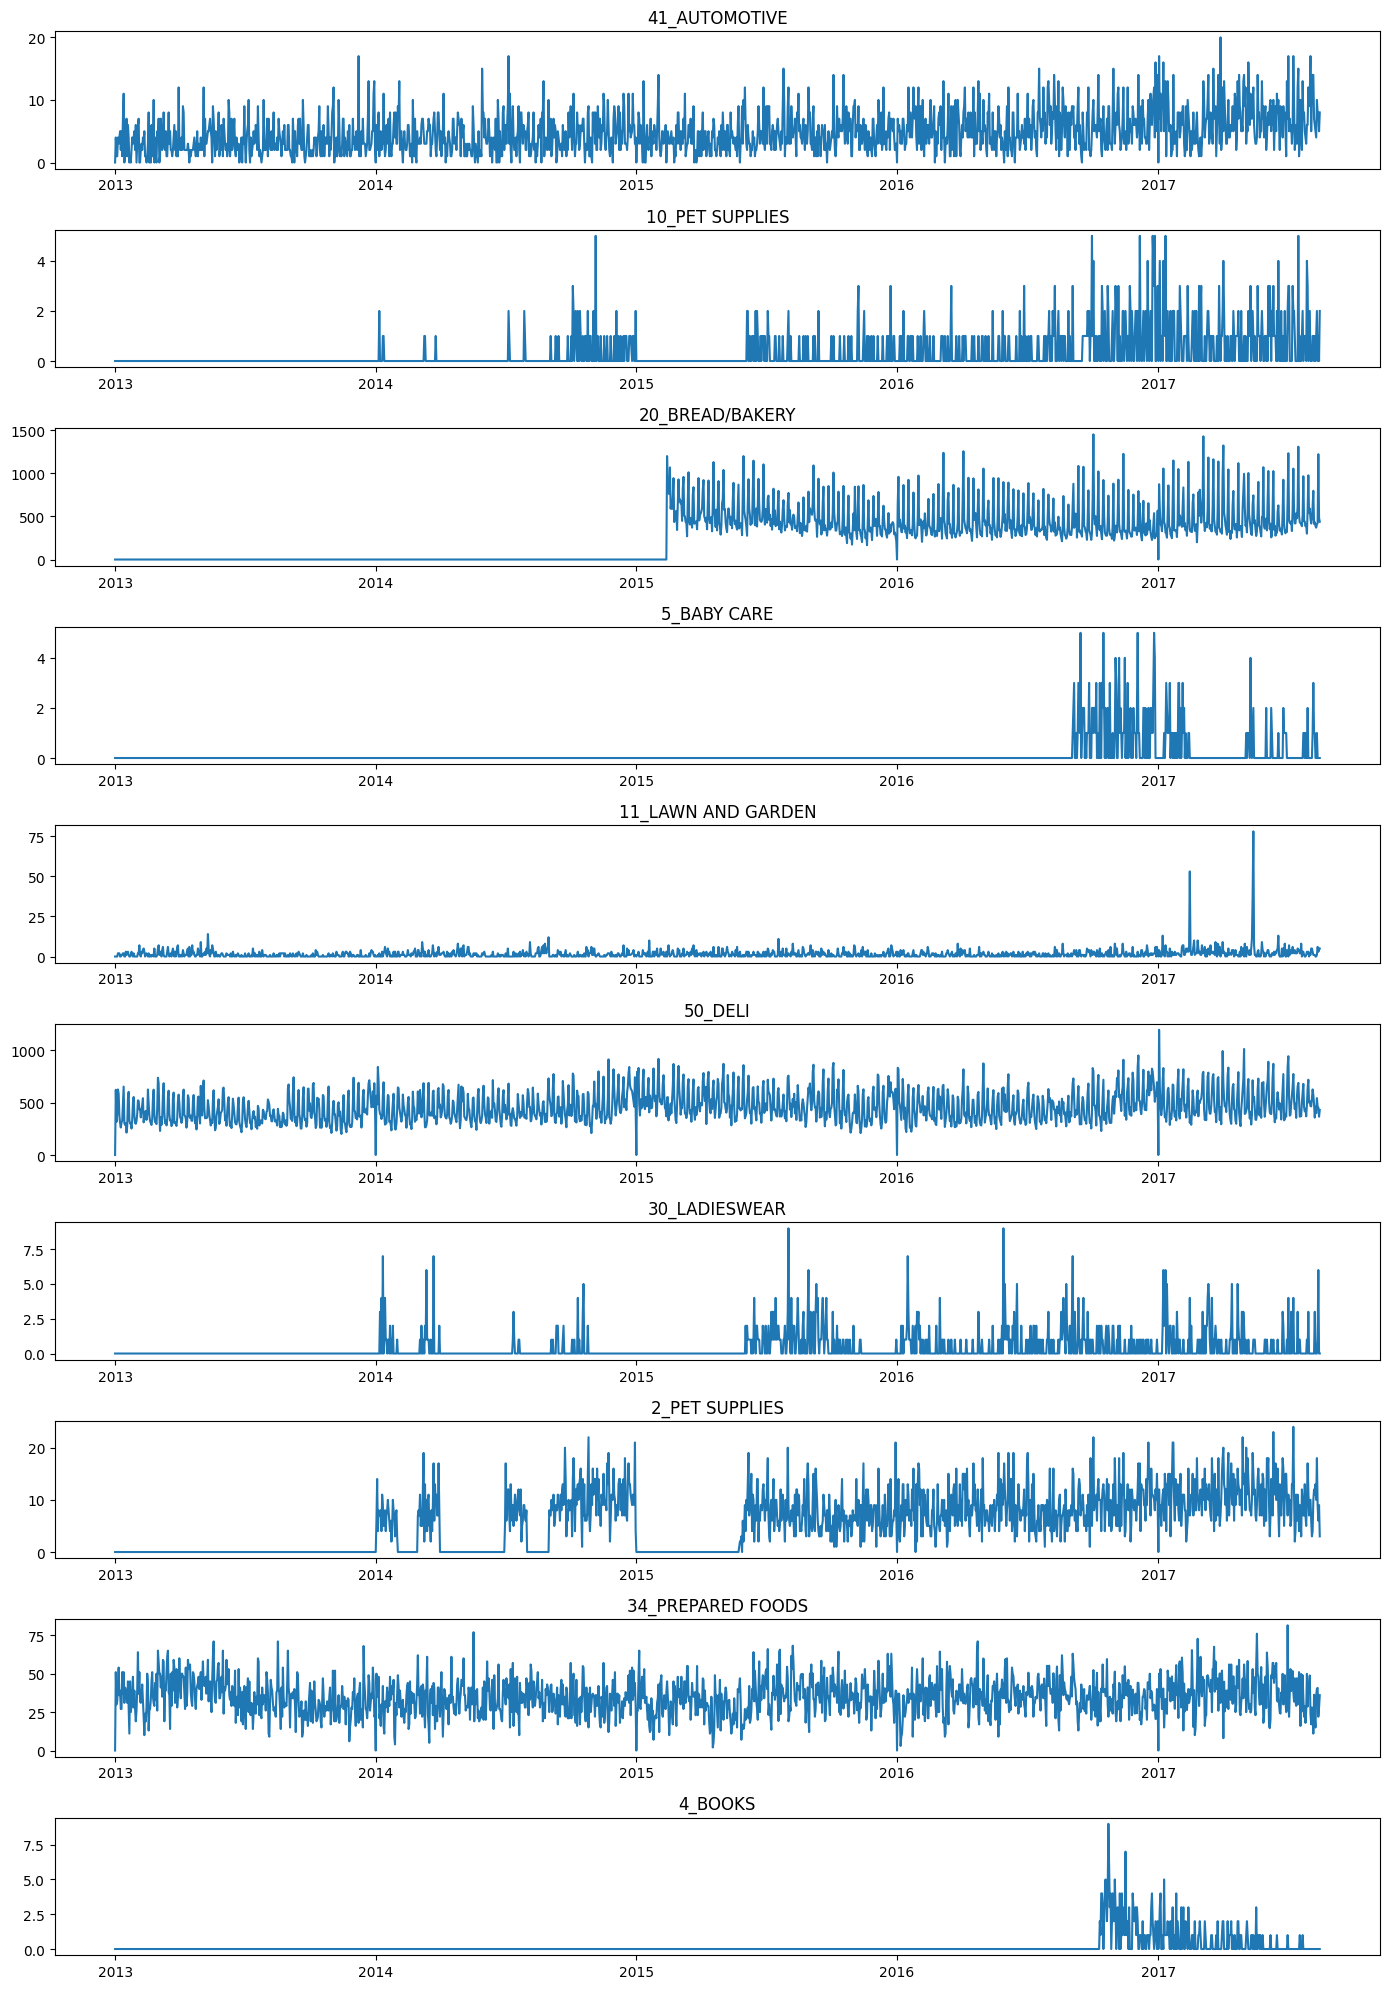

In [22]:
# Plot a few series to see patterns
fix, axes = plt.subplots(10, 1, figsize=(14, 20))
sample_ids = df['unique_id'].sample(n=10, random_state=1)
for uid, ax in zip(sample_ids, axes):
    subset = df[df['unique_id'] == uid]
    ax.plot(subset['ds'], subset['y'])
    ax.set_title(uid)
plt.tight_layout()
plt.savefig('eda_sample_series.png')
plt.show()

In [23]:
# Top 10 intermittent series
intermittent = df.groupby('unique_id')['y'].apply(lambda x: (x == 0).mean())
print(f"\n Top 10 most intermittent series:")
print(intermittent.sort_values(ascending=False).head(10))


 Top 10 most intermittent series:
unique_id
9_BOOKS               1.0
54_LAWN AND GARDEN    1.0
54_BOOKS              1.0
54_LADIESWEAR         1.0
11_BOOKS              1.0
10_BOOKS              1.0
17_BOOKS              1.0
16_BOOKS              1.0
25_LADIESWEAR         1.0
28_BOOKS              1.0
Name: y, dtype: float64


# StatsForecast Baseline

## Data Subsetting and Train-Test Split

In [24]:
print(df['unique_id'].nunique())

1782


In [25]:
# SUBSET first
subset_categories = ['1_BEVERAGES', '34_PREPARED FOODS', '8_CLEANING', '33_DAIRY', '10_GROCERY I']

In [26]:
df_sample = df[df['unique_id'].isin(subset_categories)].copy()

In [27]:
# Split: last 16 days as test (Kaggle uses 16-day horizon)
# df_sample['ds'] = pd.to_datetime(df_sample['ds']).dt.normalize()

max_date_per_series = df_sample.groupby('unique_id', as_index=False)['ds'].transform('max')

cutoff = max_date_per_series - pd.Timedelta(days=16)
train_df = df_sample[df_sample['ds'] <= cutoff]
test_df = df_sample[df_sample['ds'] > cutoff]

In [28]:
print(train_df['ds'].max(), test_df['ds'].min())

2017-07-30 00:00:00 2017-07-31 00:00:00


In [29]:
train_df.shape

(8340, 3)

In [30]:
train_df.groupby('unique_id').mean()

,ds,y
unique_id,,
10_GROCERY I,2015-04-16 07:57:24.604316416,2445.855020
1_BEVERAGES,2015-04-16 07:57:24.604316416,1583.754796
33_DAIRY,2015-04-16 07:57:24.604316416,384.465827
34_PREPARED FOODS,2015-04-16 07:57:24.604316416,35.011509
8_CLEANING,2015-04-16 07:57:24.604316416,1262.065947


In [31]:
test_df.shape

(80, 3)

## Model Training and Forecast

In [32]:
# Function to evaluate each model for each series

def evaluate_models(eval_df: pd.DataFrame, model_cols: list) -> pd.DataFrame:
    results = []
    for uid in eval_df['unique_id'].unique():
        mask = eval_df['unique_id'] == uid
        for model in model_cols: 
            mae = mean_absolute_error(eval_df.loc[mask, 'y'], eval_df.loc[mask, model])
            rsme = np.sqrt(mean_squared_error(eval_df.loc[mask, 'y'], eval_df.loc[mask, model]))
            rmsle = root_mean_squared_log_error(eval_df.loc[mask, 'y'], eval_df.loc[mask, model])
            results.append({'unique_id': uid, 'model': model, 'MAE': mae, 'RMSE': rsme, 'RMSLE': rmsle})


    return pd.DataFrame(results)

In [33]:
# Define models
from statsforecast import StatsForecast
from statsforecast.models import (
    AutoARIMA,
    AutoETS,
    AutoCES,
    CrostonOptimized, # For intermittent demand
    SeasonalNaive, 
    HistoricAverage
)
from statsforecast.utils import ConformalIntervals # This allow to calculate the Confidence intervals

# Parameters
horizon = 16
season_length = 7
freq = 'D' # Daily data
conf_level = 90
n_windows = 2

intervals = ConformalIntervals(h=horizon, n_windows=n_windows) # TODO: How this works.

models = [
    AutoARIMA(season_length=season_length, prediction_intervals=intervals),
    AutoETS(season_length=season_length, prediction_intervals=intervals),
    AutoCES(season_length=season_length, prediction_intervals=intervals),
    CrostonOptimized(prediction_intervals=intervals), # Intermittent demand
    SeasonalNaive(season_length=season_length, prediction_intervals=intervals), 
    HistoricAverage(prediction_intervals=intervals)
]

model_names = [type(model).__name__ for model in models]

params_to_log = {
    "forecast_horizon": horizon,
    "forecast_conf_level": conf_level,
    "sf_season_length": season_length,
    "sf_models": model_names,
    "sf_freq": freq,
    "interval_type": "Conformal",
    "interval_n_windows": n_windows,
}

# Feature Set
standard_cols = ['unique_id', 'ds', 'y']
exogenous_features = [col for col in train_df.columns if col not in standard_cols]

import time

with mlflow.start_run(run_name="statsforecast/baseline/2026-08-26") as run:
    start_time = time.perf_counter()
    # Log dataset metadata
    dataset = mlflow.data.from_pandas(
        train_df, 
        source=f"/home/{os.getenv('USER')}/.cache/kagglehub/competitions/{competition_name}/train.csv",
        name='training_dataset'
    )

    mlflow.log_input(dataset, context="training")
    print("Dataset metadata logged successfully.")

    # Log architecture parameters
    mlflow.log_params(params_to_log)
    print("Parameters logged successfully.")


    # Log feature set
    mlflow.log_dict({"baseline_features": standard_cols}, "feature_sets/features.json")
    print("Feature set logged successfully.")


    # Fit and forecast
    sf = StatsForecast(
        models=models, 
        freq=freq,
        n_jobs=-1, # Parallel
    )


    sf.save(path="statsforecast_models")
    mlflow.log_artifacts("statsforecast_models", 
                         artifact_path = "statsforecast_models")

    with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as tmp_file:
        joblib.dump(sf, tmp_file.name)
        mlflow.log_artifact(tmp_file.name, "model")
        print(f"StatsForecast model saved and logged to MLflow at {tmp_file.name}")

    # Use .forecast() for speed (no fitted values stored)
    forecasts = sf.forecast(df=train_df, h=horizon, level=[conf_level])
    print("Generated StatsForecasts.")

    end_time = time.perf_counter()
    run_time = end_time - start_time
    mlflow.log_metric("training_time_in_seconds", run_time)


    # Models Evaluation
    eval_df = test_df.merge(forecasts.reset_index(), on=['unique_id', 'ds'])
    model_cols = [c for c in forecasts.columns if not c in ['unique_id', 'ds'] and 'lo' not in c and 'hi' not in c]
    result_df = evaluate_models(eval_df=eval_df, model_cols=model_cols)

    for _, row in result_df.iterrows():
        mlflow.log_metrics({
            f"{row['model']}_MAE": row['MAE'],
            f"{row['model']}_RMSE": row['RMSE'],
            f"{row['model']}_RMSLE": row['RMSLE']
        })

    

Dataset metadata logged successfully.
Parameters logged successfully.
Feature set logged successfully.
Saving StatsForecast object of size 941.00B.
StatsForecast object saved
StatsForecast model saved and logged to MLflow at /tmp/tmptdbml3ut.joblib
Generated StatsForecasts.


In [34]:
print(forecasts.head(6))

      unique_id         ds    AutoARIMA  AutoARIMA-lo-90  AutoARIMA-hi-90  \
0  10_GROCERY I 2017-07-31  2569.534459      2136.986125      3002.082793   
1  10_GROCERY I 2017-08-01  2417.180103      2015.748619      2818.611588   
2  10_GROCERY I 2017-08-02  2156.179594      1453.371468      2858.987720   
3  10_GROCERY I 2017-08-03  2118.120378      1355.450945      2880.789812   
4  10_GROCERY I 2017-08-04  2085.035325      1197.476023      2972.594628   
5  10_GROCERY I 2017-08-05  3080.786735      2784.339821      3377.233649   

       AutoETS  AutoETS-lo-90  AutoETS-hi-90          CES    CES-lo-90  \
0  2556.030790    2210.074949    2901.986631  2477.989410  2104.997354   
1  2404.898036    1699.168538    3110.627533  2458.168518  2010.930013   
2  2107.988113    1103.192733    3112.783493  2158.820480  1387.308097   
3  2057.973883    1032.230578    3083.717188  2131.527809  1309.742735   
4  2007.584936     816.709761    3198.460111  2067.917534  1124.126524   
5  3051.338191  

## Evaluation

In [35]:
test_df.columns

Index(['unique_id', 'ds', 'y'], dtype='object')

In [36]:
# Evaluation
eval_df = test_df.merge(forecasts.reset_index(), on=['unique_id', 'ds'])
model_cols = [c for c in forecasts.columns if not c in ['unique_id', 'ds'] and 'lo' not in c and 'hi' not in c]

In [37]:
model_cols

['AutoARIMA',
 'AutoETS',
 'CES',
 'CrostonOptimized',
 'SeasonalNaive',
 'HistoricAverage']

In [38]:

# Evaluate each model for each series
mask = eval_df['unique_id'] == '8_CLEANING'
print(mean_absolute_error(eval_df.loc[mask, 'y'], eval_df.loc[mask, 'AutoARIMA']))

224.21452195923595


In [39]:

def print_evaluation_results(results_df: pd.DataFrame):
    print("\n=== Model Comparison ===")
    print(results_df.pivot_table(index='model', values=['MAE', 'RMSE', 'RMSLE'], aggfunc='mean').round(2))

    best_mae = results_df.loc[results_df.groupby('unique_id')['MAE'].idxmin()]
    print("\n=== Best Model per Series (MAE) ===")
    print(best_mae[['unique_id', 'model', 'MAE']])

    best_rmse = results_df.loc[results_df.groupby('unique_id')['RMSE'].idxmin()]
    print("\n=== Best Model per Series (RMSE) ===")
    print(best_rmse[['unique_id', 'model', 'RMSE']])

    best_rmsle = results_df.loc[results_df.groupby('unique_id')['RMSLE'].idxmin()]
    print("\n=== Best Model per Series (RMSLE) ===")
    print(best_rmsle[['unique_id', 'model', 'RMSLE']])

In [40]:
results_df = evaluate_models(eval_df, model_cols)
print_evaluation_results(results_df)


=== Model Comparison ===
                     MAE    RMSE  RMSLE
model                                  
AutoARIMA         217.63  281.27   0.27
AutoETS           213.65  277.38   0.27
CES               209.49  275.64   0.26
CrostonOptimized  240.90  296.35   0.29
HistoricAverage   288.45  326.60   0.30
SeasonalNaive     248.61  315.21   0.31

=== Best Model per Series (MAE) ===
            unique_id            model         MAE
8        10_GROCERY I              CES  473.208806
1         1_BEVERAGES          AutoETS  280.919764
13           33_DAIRY          AutoETS   63.624504
20  34_PREPARED FOODS              CES    9.501038
29         8_CLEANING  HistoricAverage  184.649730

=== Best Model per Series (RMSE) ===
            unique_id             model        RMSE
9        10_GROCERY I  CrostonOptimized  568.831528
4         1_BEVERAGES     SeasonalNaive  432.269881
12           33_DAIRY         AutoARIMA   75.261035
20  34_PREPARED FOODS               CES   11.660467
29         8_

## Cross-Validation

In [ ]:
# StatForecast has built-in time series cross-validation

# Parameteers for cross-validation
horizon = 16
step_size = 16
n_windows = 3
conf_level = 90

params_to_log_cv = {
    "forecast_horizon": horizon,
    "sf_models": model_names,
    "sf_freq": "D",
    "step_size": step_size,
    "conf_level": conf_level,
    "interval_n_windows": n_windows,
}

# Feature Set
standard_cols = ['unique_id', 'ds', 'y']

with mlflow.start_run(run_name="statsforecast/crossval_baseline/2026-08-26") as run:

    # Log dataset metadata
    dataset = mlflow.data.from_pandas(
        df_sample, 
        source=f"/home/{os.getenv('USER')}/.cache/kaggle/competitions/{competition_name}/train.csv",
        name='crossval_dataset_baseline'
    )

    mlflow.log_input(dataset, context="crossval")
    print("Dataset metadata logged successfully.")

    # Log architecture parameters
    mlflow.log_params(params_to_log_cv)
    print("Parameters logged successfully.")


    # Log feature set
    mlflow.log_dict({"baseline_features": standard_cols}, "feature_sets/baseline_features.json")
    print("Feature set logged successfully.")
    
    crossval = sf.cross_validation(
        df=df_sample,
        h=horizon,  # Forecast horizon 
        step_size=step_size, # Non-overlapping windows
        n_windows=n_windows, # 3 folds
        level=[conf_level], # Confidence intervals
        n_jobs=-1, # Parallel
    )

    print("Cross-validation completed successfully.")

    all_folds_metrics = []

    # Log cross-validation metrics per fold
    for fold_idx, (cutoff, fold_df) in enumerate(crossval.groupby('cutoff')):
        result = evaluate(fold_df.drop(columns=['cutoff']),
                          metrics=[mae, rmse, rmsle]
        )

        mean_metrics = result.drop(columns=['unique_id']).groupby('metric').mean()

        fold_dict = {}

        for metric_name, row in mean_metrics.iterrows():
            for model_name, value in row.items():
                key = f"{model_name}_{metric_name}"
                fold_dict[key] = value
                
        mlflow.log_metrics(fold_dict, step=fold_idx)

        all_folds_metrics.append(fold_dict)


    cv_results_df = pd.DataFrame(all_folds_metrics)

    aggregated_metrics = {}

    for model in cv_results_df.columns:
        aggregated_metrics[f"{model}_cv_mean"]= cv_results_df[model].mean()
        aggregated_metrics[f"{model}_cv_std"] = cv_results_df[model].std()

    mlflow.log_metrics(aggregated_metrics)

    print("Logged individual fold metrics and aggregated totals of the CV.")
    print(crossval.head())

Dataset metadata logged successfully.
Parameters logged successfully.
Feature set logged successfully.
Cross-validation completed successfully.
Logged individual fold metrics and aggregated totals of the CV.
      unique_id         ds     cutoff       y    AutoARIMA  AutoARIMA-lo-90  \
0  10_GROCERY I 2017-06-29 2017-06-28  1937.0  1857.617661      1401.192288   
1  10_GROCERY I 2017-06-30 2017-06-28  2473.0  2006.291239      1755.126189   
2  10_GROCERY I 2017-07-01 2017-06-28  3953.0  3156.018506      2766.043552   
3  10_GROCERY I 2017-07-02 2017-06-28  3783.0  2934.627614      2251.514253   
4  10_GROCERY I 2017-07-03 2017-06-28  3599.0  2590.299028      2160.962254   

   AutoARIMA-hi-90      AutoETS  AutoETS-lo-90  AutoETS-hi-90  ...  \
0      2314.043035  1673.130670    1242.825943    2103.435396  ...   
1      2257.456289  1691.170779    1259.280473    2123.061084  ...   
2      3545.993459  2793.803948    2020.172186    3567.435710  ...   
3      3617.740975  2582.000365    15

In [43]:
print("\n=== MAE ===")
for model in model_cols:
    mae = mean_absolute_error(crossval['y'], crossval[model])
    print(f"{model}: CV MAE = {mae:.2f}")

print("\n=== RMSE ===")
for model in model_cols:
    rmse = np.sqrt(mean_squared_error(crossval['y'], crossval[model]))
    print(f"{model}: CV RMSE = {rmse:.2f}")

print("\n=== RMSLE ===")
for model in model_cols:
    rmsle = root_mean_squared_log_error(crossval['y'], crossval[model])
    print(f"{model}: CV RMSLE = {rmsle:.2f}")



=== MAE ===
AutoARIMA: CV MAE = 172.94
AutoETS: CV MAE = 181.76
CES: CV MAE = 168.93
CrostonOptimized: CV MAE = 232.36
SeasonalNaive: CV MAE = 191.77
HistoricAverage: CV MAE = 297.38

=== RMSE ===
AutoARIMA: CV RMSE = 280.70
AutoETS: CV RMSE = 304.49
CES: CV RMSE = 279.17
CrostonOptimized: CV RMSE = 381.46
SeasonalNaive: CV RMSE = 326.49
HistoricAverage: CV RMSE = 444.68

=== RMSLE ===
AutoARIMA: CV RMSLE = 0.24
AutoETS: CV RMSLE = 0.24
CES: CV RMSLE = 0.23
CrostonOptimized: CV RMSLE = 0.29
SeasonalNaive: CV RMSLE = 0.26
HistoricAverage: CV RMSLE = 0.31


## Forecast Visualization

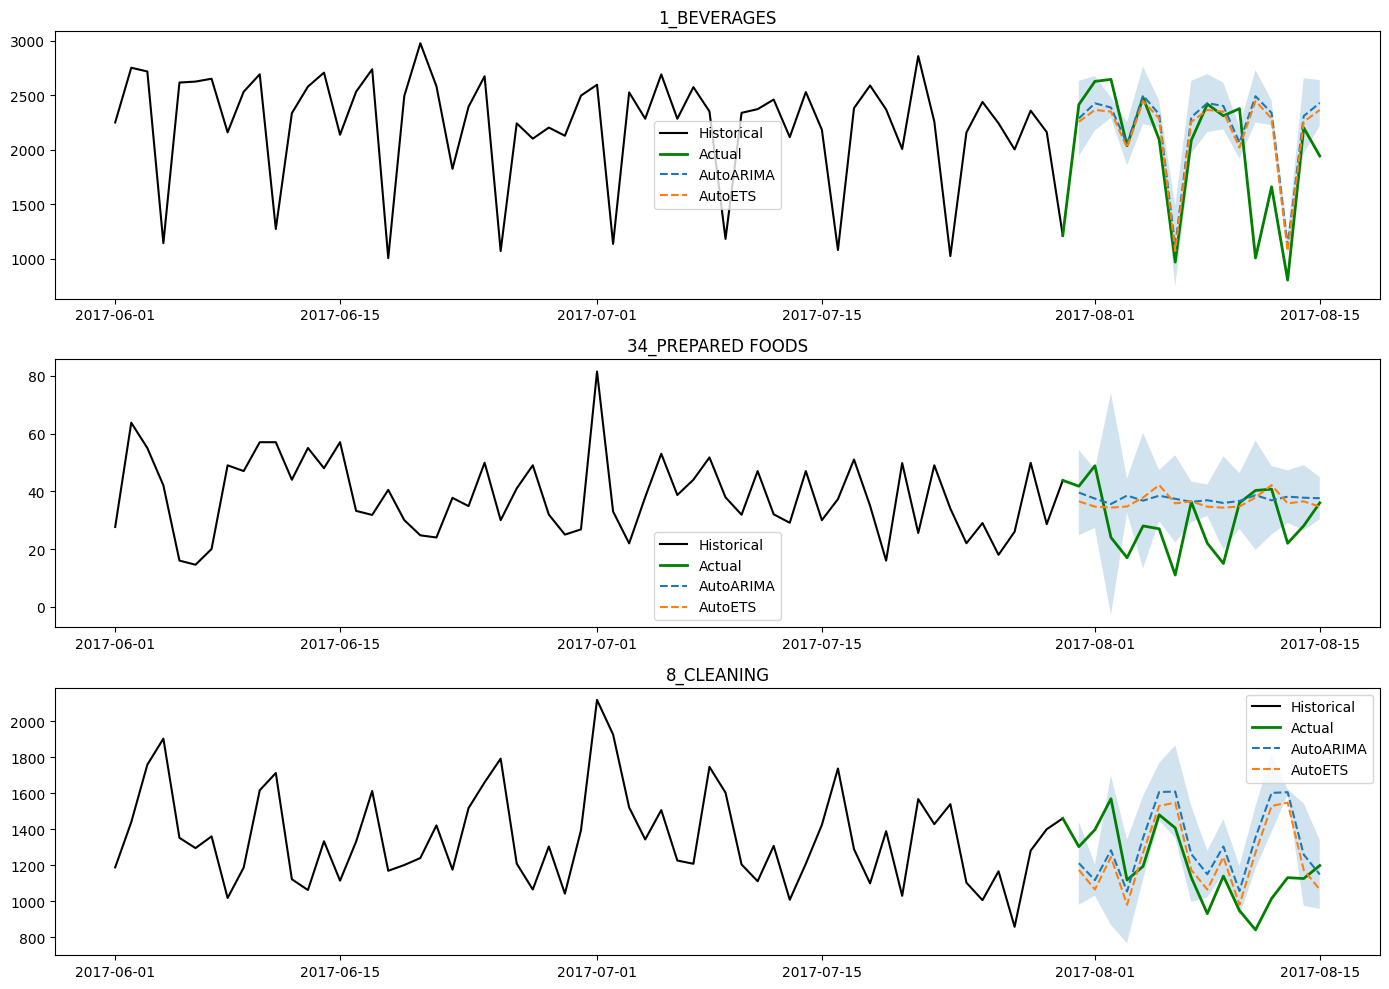

In [44]:
# Plot forecasts vs actual for 2-3 series
fig, axes = plt.subplots(len(subset_categories[:3]), 1, figsize=(14,10))
for ax, uid in zip(axes, subset_categories[:3]):
    # Historical
    hist = train_df[train_df['unique_id'] == uid].tail(60)
    ax.plot(hist['ds'], hist['y'], label='Historical', color='black')

    # Actuals in test period
    actual = test_df[test_df['unique_id'] == uid]
    actual = pd.concat([train_df[train_df['unique_id'] == uid].tail(1), actual])
    ax.plot(actual['ds'], actual['y'], label='Actual', color='green', linewidth=2)

    # Forecast (best 2 models)
    fc = forecasts.reset_index()
    fc_uid = fc[fc['unique_id'] == uid]
    ax.plot(fc_uid['ds'], fc_uid['AutoARIMA'], label='AutoARIMA', linestyle='--')
    ax.plot(fc_uid['ds'], fc_uid['AutoETS'], label='AutoETS', linestyle='--')

    # Confidence interval
    if 'AutoARIMA-lo-90' in fc_uid.columns:
        ax.fill_between(fc_uid['ds'], fc_uid['AutoARIMA-lo-90'],
                        fc_uid['AutoARIMA-hi-90'], alpha=0.2)
    ax.set_title(uid)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150)
plt.show()

# Stretch Goals (if time allows)

- [x] Add oil.csv as exogenous variable to AutoARIMA
- [x] Try NeuralForecast: NHITS, PatchTST on same data
- [x] Add MLflow tracking for experiment logging
- [ ] Hierarchical forecasting: store-level → family-level reconciliation

# Exogenous Variables: Oil Price

## Data Loading

In [45]:
oil_df = pd.read_csv(path + '/oil.csv', parse_dates=['date'])

In [46]:
print(f"{oil_df.head(5)}", f"\n {oil_df.tail(5)}")

        date  dcoilwtico
0 2013-01-01         NaN
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07       93.20 
            date  dcoilwtico
1213 2017-08-25       47.65
1214 2017-08-28       46.40
1215 2017-08-29       46.46
1216 2017-08-30       45.96
1217 2017-08-31       47.26


## Missing Values

In [47]:
oil_df.isna().sum()

date           0
dcoilwtico    43
dtype: int64

In [48]:
oil_df = oil_df.ffill()


In [49]:
oil_df.isna().sum()

date          0
dcoilwtico    1
dtype: int64

In [50]:
oil_df = oil_df.rename(columns={'dcoilwtico': 'oil_price'})

## Merge with Training and Test Data

In [51]:
exo_train_df = train_df.copy().merge(oil_df, right_on='date', left_on='ds', how='left').drop(columns='date')

In [52]:
exo_train_df.isna().sum()

unique_id       0
ds              0
y               0
oil_price    2390
dtype: int64

In [53]:
exo_test_df = test_df.copy().merge(oil_df, right_on='date', left_on='ds', how='left').drop(columns='date')

In [54]:
exo_test_df.isna().sum()

unique_id     0
ds            0
y             0
oil_price    20
dtype: int64

In [55]:
exo_test_df[exo_test_df['oil_price'].isna()]

,unique_id,ds,y,oil_price
25,1_BEVERAGES,2017-08-05,2093.000,NaN
26,10_GROCERY I,2017-08-05,3428.000,NaN
27,33_DAIRY,2017-08-05,459.000,NaN
28,34_PREPARED FOODS,2017-08-05,27.000,NaN
29,8_CLEANING,2017-08-05,1480.000,NaN
30,1_BEVERAGES,2017-08-06,968.000,NaN
31,10_GROCERY I,2017-08-06,3525.000,NaN
32,33_DAIRY,2017-08-06,574.000,NaN
33,34_PREPARED FOODS,2017-08-06,11.000,NaN
34,8_CLEANING,2017-08-06,1407.000,NaN


In [56]:
# Front and back fill with valid values after left join.
exo_test_df['oil_price'] = exo_test_df['oil_price'].ffill().bfill()
exo_train_df['oil_price'] = exo_train_df['oil_price'].ffill().bfill()

In [57]:
exo_train_df.isna().sum()

unique_id    0
ds           0
y            0
oil_price    0
dtype: int64

In [58]:
print(exo_test_df.shape, test_df.shape)
print(exo_test_df.columns)

(80, 4) (80, 3)
Index(['unique_id', 'ds', 'y', 'oil_price'], dtype='object')


## Model Training and Forecast

In [ ]:


# Parameters
horizon = 16
season_length = 7
freq = 'D' # Daily data
conf_level = 90
n_windows = 2

intervals = ConformalIntervals(h=horizon, n_windows=n_windows) # TODO: How this works.

models = [
    AutoARIMA(season_length=season_length, prediction_intervals=intervals),
    AutoETS(season_length=season_length, prediction_intervals=intervals),
    AutoCES(season_length=season_length, prediction_intervals=intervals),
    CrostonOptimized(prediction_intervals=intervals), # Intermittent demand
    SeasonalNaive(season_length=season_length, prediction_intervals=intervals), 
    HistoricAverage(prediction_intervals=intervals)
]

model_names = [type(model).__name__ for model in models]

params_to_log = {
    "forecast_horizon": horizon,
    "forecast_conf_level": conf_level,
    "sf_season_length": season_length,
    "sf_models": model_names,
    "sf_freq": freq,
    "interval_type": "Conformal",
    "interval_n_windows": n_windows,

} 

sources = [
    f"/home/{os.getenv('USER')}/.cache/kagglehub/competitions/{competition_name}/train.csv",
    f"/home/{os.getenv('USER')}/.cache/kagglehub/competitions/{competition_name}/oil.csv"
]

combined_sources= "|".join(sources)

# Feature Set
standard_cols = ['unique_id', 'ds', 'y']
exogenous_features = [col for col in exo_train_df.columns if col not in standard_cols]


with mlflow.start_run(run_name="statsforecast/baseline+oil/2026-08-27") as run:

    # Log dataset metadata
    dataset = mlflow.data.from_pandas(
        exo_train_df,
        source=combined_sources,
        name='training_dataset_with_oil_exogenous'
    )
    mlflow.log_input(dataset, context="training_with_oil_exogenous")
    print("Dataset metadata logged successfully.")

    # Log architecture parameters
    mlflow.log_params(params_to_log)
    print("Logged parameters successfully.")


    # Log feature set
    mlflow.log_dict({"baseline_features": standard_cols, "exogenous_features": exogenous_features}, "feature_sets/features.json")
    print(f"Logged {len(exogenous_features)} exogenous features artifacts")
    print(f"Feature set logged successfully.")

    # Fit and forecast
    sf = StatsForecast(
        models=models,
        freq=freq, # Daily data
        n_jobs=-1, # Parallel
    )


    sf.save(path="statsforecast_models_oil")
    mlflow.log_artifacts("statsforecast_models_oil",
                         artifact_path="statsforecast_models_oil")

    with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as tmp_file:
        joblib.dump(sf, tmp_file.name)
        mlflow.log_artifact(tmp_file.name, "model")


    # Use .forecast() for speed (no fitted values stored)
    forecasts = sf.forecast(
        df=exo_train_df,
        h=horizon,
        level=[conf_level], 
        X_df=exo_test_df[['unique_id', 'ds', 'oil_price']],
        n_jobs=-1
    )

    eval_df = exo_test_df.merge(forecasts.reset_index(), on=['unique_id', 'ds'])
    model_cols = [c for c in forecasts.columns if not c in ['unique_id', 'ds'] and 'lo' not in c and 'hi' not in c]
    results_df = evaluate_models(eval_df=eval_df, model_cols=model_cols)

    for _, row in results_df.iterrows():
        mlflow.log_metrics({
            f"{row['model']}_MAE": row["MAE"],
            f"{row['model']}_RMSE": row["RMSE"],
            f"{row['model']}_RMSLE": row["RMSLE"]
        })

    
    print("Generated forecasts with exogenous variable (oil price).")

Dataset metadata logged successfully.
Logged parameters successfully.
Logged 1 exogenous features artifacts
Feature set logged successfully.
Saving StatsForecast object of size 941.00B.
StatsForecast object saved


## Evaluation

In [ ]:
eval_df

In [ ]:
# Test evaluation for a specific series
mask = eval_df['unique_id'] == '8_CLEANING'
print(mean_absolute_error(eval_df.loc[mask, 'y'], eval_df.loc[mask, 'AutoARIMA']))

In [ ]:
print_evaluation_results(results_df)

## Cross-Validation with Exogenous Variables

In [ ]:
df_oil = df_sample.merge(oil_df, how='left', left_on='ds', right_on='date')

In [ ]:
df_oil = df_oil.drop(columns=['date'])

In [ ]:
df_oil = df_oil.ffill().bfill()

In [ ]:
# StatForecast has built-in time series cross-validation
horizon = 16
step_size = 16
n_windows = 3
conf_level = 90

params_to_log_cv = {
    "forecast_horizon": horizon,
    "sf_models": model_names,
    "sf_freq": "D",
    "step_size": step_size,
    "conf_level": conf_level,
    "interval_n_windows": n_windows,
}

# Feature Set
standard_cols = ['unique_id', 'ds', 'y']
cols_to_log = standard_cols + ['oil_price']

sources = [
    f"/home/{os.getenv('USER')}/.cache/kagglehub/competitions/{competition_name}/train.csv",
    f"/home/{os.getenv('USER')}/.cache/kagglehub/competitions/{competition_name}/oil.csv"
]   

source = "|".join(sources)


with mlflow.start_run(run_name="statsforecast/crossval_oil/2026-09-10") as run:

    mlflow.log_params(params_to_log_cv)

    mlflow.log_dict({"baseline_features": standard_cols, "exogenous_features": ['oil_price']}, "feature_sets/features.json")

    mlflow.log_input(mlflow.data.from_pandas(df_oil, source=source, name='crossval_dataset_with_oil_exogenous'), context="crossval_with_oil_exogenous")

    

    crossval_exogen = sf.cross_validation(
        df=df_oil,
        h=horizon,
        step_size=step_size, # Non-overlapping windows
        n_windows=n_windows, # 3 folds
        level=[conf_level],
    )

    model_cols = [c for c in crossval_exogen.columns if not c in ['unique_id', 'ds', 'y', 'cutoff'] and 'lo' not in c and 'hi' not in c]

    for model in model_cols:
        mlflow.log_metrics({
            f"{model}_MAE": mean_absolute_error(crossval_exogen['y'], crossval_exogen['model']),
            f"{model}_RMSE": np.sqrt(mean_squared_error(crossval_exogen['y'], crossval_exogen['model'])),
            f"{model}_RMSLE": root_mean_squared_log_error(crossval_exogen['y'], crossval_exogen['model'])
        })

    print(crossval_exogen.head())

In [ ]:
model_cols = [c for c in forecasts.columns if not c in ['unique_id', 'ds'] and 'lo' not in c and 'hi' not in c]

In [ ]:
print("\n=== MAE ===")

for model in model_cols:
    mae = mean_absolute_error(crossval_exogen['y'], crossval_exogen[model])
    print(f"{model}: CV MAE: {mae:.2f}")

print("\n=== RMSE ===")

for model in model_cols:
    rmse = np.sqrt(mean_squared_error(crossval_exogen['y'], crossval_exogen[model]))
    print(f"{model}: CV RMSE:{rmse:.2f}")

## Visualization

In [ ]:
fig, axes = plt.subplots(len(subset_categories[:3]), 1, figsize=(14,10))

for ax, uid in zip(axes, subset_categories[:3]):

    # Historical
    hist = exo_train_df[exo_train_df['unique_id'] == uid].tail(60)
    ax2 = ax.twinx()
    ax2.plot(hist['ds'], hist['oil_price'], label='Oil Price', color='black')
    ax.plot(hist['ds'], hist['y'], label='Historical', color='gold')


    # Actual in test period
    actual = exo_test_df[exo_test_df['unique_id'] == uid]
    ax.plot(actual['ds'], actual['y'], label='Actual',  color='green', linewidth=2)
    ax2.plot(actual['ds'], actual['oil_price'], label='Oil_price',  color='black', linewidth=2)
    
    
    ax.set_title(uid)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('forecast_with_oil_price_comparison.png', dpi=150)
plt.show()
    

# NeuralForecast

## Setup

In [ ]:
import logging
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, GRU, RNN, NHITS, PatchTST

In [ ]:
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)

## Model Training

In [ ]:
train_df.head(1)
val_df = train_df[train_df['ds'] > train_df['ds'].max() - pd.Timedelta(days=16)]
train_df = train_df[train_df['ds'] <= train_df['ds'].max() - pd.Timedelta(days=16)]

In [ ]:
%%capture

# Paramaters
horizon = 16
input_size = 2 * horizon # Input size for the neural network
freq = 'D' # Daily data
max_steps = 500
encoder_hidden_size = 64 # Number of cells in the encoder in LSTM, GRU, RNN
decoder_hidden_size = 64 # MLP number of neurons in each layer
scaler_type = 'standard' # StandardScaler or MinMaxScaler
n_windows = 2 # Number of windows for conformal intervals
intervals = ConformalIntervals(h=horizon, n_windows=n_windows) # TODO: How this works.

models = [
    LSTM(input_size=input_size,
         h=horizon,
         max_steps=max_steps,
         scaler_type=scaler_type,
         encoder_hidden_size=encoder_hidden_size,
         decoder_hidden_size=decoder_hidden_size,
        ),
    
    GRU(input_size=input_size,
         h=horizon,
         max_steps=max_steps,
         scaler_type=scaler_type,
         encoder_hidden_size=encoder_hidden_size,
         decoder_hidden_size=decoder_hidden_size,
        ),
    RNN(input_size=input_size,
         h=horizon,
         max_steps=max_steps,
         scaler_type=scaler_type,
         encoder_hidden_size=encoder_hidden_size,
         decoder_hidden_size=decoder_hidden_size,
        ),
    NHITS(input_size=input_size,
          h=horizon,
          max_steps=max_steps,
          scaler_type=scaler_type,
    ),
    PatchTST(input_size=input_size,
          h=horizon,
          max_steps=max_steps,
          scaler_type=scaler_type,
    ),  
    
]

model_names = [type(model).__name__ for model in models]

params_to_log = {
    "nf_horizon": horizon,
    "nf_input_size": input_size,
    "nf_max_steps": max_steps,
    "nf_models": model_names,
    "nf_encoder_hidden_size": encoder_hidden_size,
    "nf_decoder_hidden_size": decoder_hidden_size,
    "nf_scaler_type": scaler_type,
    "interval_type": "Conformal",
    "interval_n_windows": n_windows,
}


standard_cols = ['unique_id', 'ds', 'y']
exogenous_features = [col for col in train_df.columns if col not in standard_cols]


with mlflow.start_run(run_name="neuralforecast/baseline/2026-08-27") as run:
    
    # Log dataset metadata 
    dataset = mlflow.data.from_pandas(
        train_df,
        source=f"kaggle://competitions/{competition_name}/train.csv",
        name='training_dataset'
    )
    mlflow.log_input(dataset, context="training")
    print("Dataset metadata logged successfully.")

    # Log architecture parameters
    mlflow.log_params(params_to_log)
    print("Parameters logged successfully.")

    # Log feature set
    mlflow.log_dict({"baseline_features": standard_cols, "exogenous_features": exogenous_features}, "feature_sets/features.json")
    print(f"Logged {len(exogenous_features)} exogenous features artifacts")
    print(f"Feature set logged successfully.")

    nf = NeuralForecast(models=models, freq=freq)

    start_time = time.perf_counter()
    nf.fit(df=train_df, prediction_intervals=intervals, n_jobs=-1)

    end_time = time.perf_counter()
    print(f"Model fitting time: {end_time - start_time:.2f} seconds")
    mlflow.log_metric("training_time_in_seconds", end_time - start_time)

    nf.save(path="neuralforecast_models")
    mlflow.log_artifacts("neuralforecast_models",
        artifact_path="neuralforecast_models")
    
    with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as tmp_file:
        joblib.dump(nf, tmp_file.name)
        mlflow.log_artifact(tmp_file.name, "model")
        print(f"NeuralForecast model saved and logged to MLflow at {tmp_file.name}")



    print("NeuralForecast models fitted successfully.")

## Prediction and Evaluation

In [ ]:
with mlflow.start_run(run_name="neuralforecast/baseline_test/2026-09-10") as run:
    
    # Log dataset metadata 
    dataset = mlflow.data.from_pandas(
        val_df,
        source=f"/home/{os.getenv('USER')}/.cache/kagglehub/competitions/{competition_name}/test.csv",
        name='test_dataset'
    )
    mlflow.log_input(dataset, context="test")
    print("Dataset metadata logged successfully.")

    # Log architecture parameters
    mlflow.log_params(params_to_log)
    print("Parameters logged successfully.")

    # Log feature set
    mlflow.log_dict({"baseline_features": standard_cols, "exogenous_features": exogenous_features}, "feature_sets/features.json")
    print(f"Logged {len(exogenous_features)} exogenous features artifacts")
    print(f"Feature set logged successfully.")

    start_time = time.perf_counter()
    
    y_hat = nf.predict(df=val_df)

    end_time = time.perf_counter()
    print(f"Inference time: {end_time - start_time:.2f} seconds")

    model_cols = [c for c in y_hat.columns if not c in ['unique_id', 'ds'] and 'lo' not in c and 'hi' not in c]
    results_df = evaluate_models(eval_df, model_cols)

    for _, row in results_df.iterrows():
        mlflow.log_metrics({
            f"{row['model']}_MAE": row["MAE"],
            f"{row['model']}_RMSE": row["RMSE"],
            f"{row['model']}_RMSLE": row["RMSLE"]
        })


In [ ]:
y_hat.head(10)

In [ ]:

print_evaluation_results(results_df)

In [ ]:
fig, axes = plt.subplots(len(subset_categories[:3]), 1, figsize=(14,10))
for ax, uid in zip(axes, subset_categories[:3]):
    # Historical
    hist = train_df[train_df['unique_id'] == uid].tail(60)
    ax.plot(hist['ds'], hist['y'], label='Historical', color='black')

    # Actuals in test period
    actual = test_df[test_df['unique_id'] == uid]
    ax.plot(actual['ds'], actual['y'], label='Actual', color='green', linewidth=2)

    # Forecast (best 2 models)
    fc = y_hat.reset_index()
    fc_uid = fc[fc['unique_id'] == uid]
    ax.plot(fc_uid['ds'], fc_uid['LSTM'], label='LSTM', linestyle='--')
    ax.plot(fc_uid['ds'], fc_uid['RNN'], label='RNN', linestyle='--')
    ax.plot(fc_uid['ds'], fc_uid['GRU'], label='GRU', linestyle='--')
    ax.plot(fc_uid['ds'], fc_uid['NHITS'], label='NHITS', linestyle='--')
    ax.plot(fc_uid['ds'], fc_uid['PatchTST'], label='PatchTST', linestyle='--')

    # Confidence interval
    if 'AutoARIMA-lo-90' in fc_uid.columns:
        ax.fill_between(fc_uid['ds'], fc_uid['AutoARIMA-lo-90'],
                        fc_uid['AutoARIMA-hi-90'], alpha=0.2)
    ax.set_title(uid)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150)
plt.show()